# Titanic Survival Prediction – Heuristic Approach

This notebook explores heuristic‑based prediction of Titanic passenger survival.  
We implement two simple decision rules and evaluate their accuracy against the actual outcomes.

**Dataset**: The Titanic passenger list from Kaggle (891 records).  
**Goal**: Achieve >80% accuracy using only a few interpretable features.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import urllib.request

%matplotlib inline
sns.set_style('whitegrid')

### Load dataset 
Note: If you don't have the file locally, you can download it with

In [8]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
path = "data/titanic.csv"

os.makedirs("data", exist_ok=True)

if not os.path.exists(path):
    urllib.request.urlretrieve(url, path)
    print("Titanic dataset downloaded.")
else:
    print("Dataset already exists.")

# Load dataset (adjust path if needed)

df = pd.read_csv('data/titanic.csv')  # or directly from URL
print("Dataset shape:", df.shape)
df.head()

Dataset already exists.
Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df.info()
print("\nMissing values:")
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Exploratory Data Analysis

We examine survival rates across different features to inform our heuristics.

Survival rate by gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


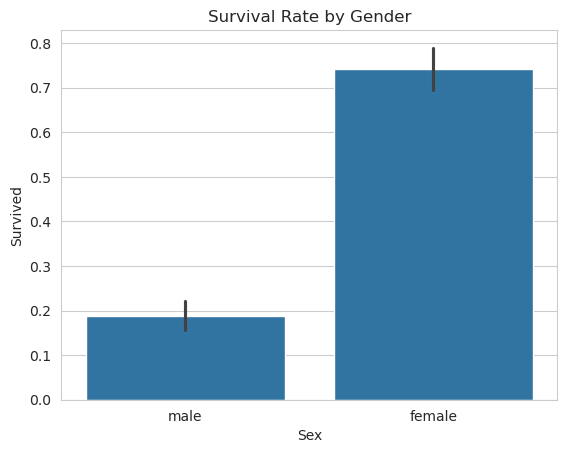

In [10]:
# Survival by gender
survived_by_sex = df.groupby('Sex')['Survived'].mean()
print("Survival rate by gender:")
print(survived_by_sex)

# Plot
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Gender')
plt.show()

Survival rate by passenger class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


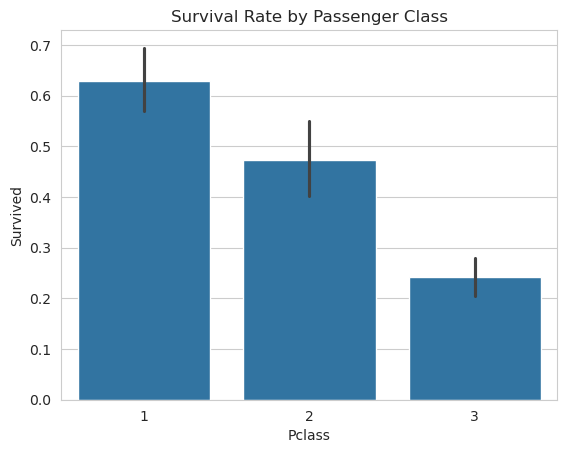

In [11]:
# Survival by Pclass
survived_by_class = df.groupby('Pclass')['Survived'].mean()
print("Survival rate by passenger class:")
print(survived_by_class)

sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.show()

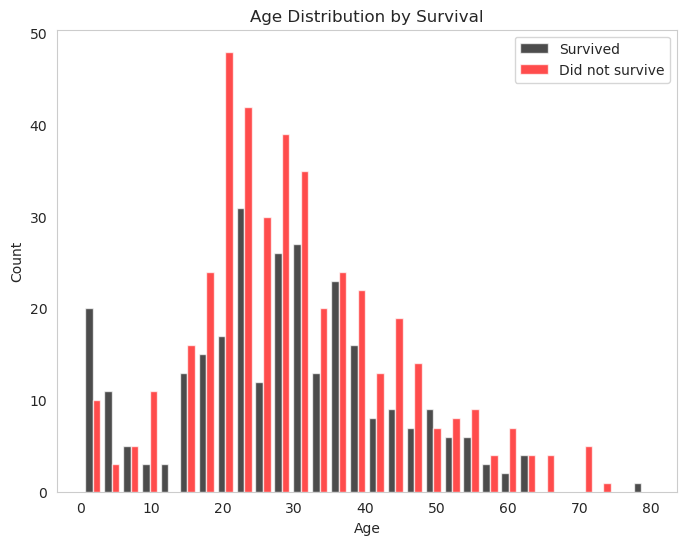

In [33]:
# Age distribution, highlighting survivors
plt.figure(figsize=(8,6))

plt.hist(
    [
        df[df['Survived'] == 1]['Age'].dropna(),
        df[df['Survived'] == 0]['Age'].dropna()
    ],
    bins=30,
    label=['Survived', 'Did not survive'],
    color=['black', 'red'],
    alpha=0.7
)

plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(False)
plt.legend()
plt.title('Age Distribution by Survival')
plt.show()

## Heuristic 1 – Complex Heuristic (from Udacity)

**Rule**: Survive if  
- female **OR**  
- (first class **AND** under 18 years old)  

We handle missing ages by treating them as *not under 18*.

In [16]:
def complex_heuristic(df):
    """
    Predict survival using the rule: female OR (first class AND under 18).
    Returns a dictionary {PassengerId: 0/1}
    """
    predictions = {}
    for _, passenger in df.iterrows():
        pid = passenger['PassengerId']
        is_female = (passenger['Sex'] == 'female')
        # Age may be NaN – treat as not under 18
        age = passenger['Age']
        is_under_18 = (not pd.isna(age)) and (age < 18)
        is_first_class = (passenger['Pclass'] == 1)
        
        if is_female or (is_first_class and is_under_18):
            predictions[pid] = 1
        else:
            predictions[pid] = 0
    return predictions

# Compute predictions
pred_complex = complex_heuristic(df)


In [17]:
# True labels
true_labels = df.set_index('PassengerId')['Survived']

# Accuracy
correct = sum(1 for pid, pred in pred_complex.items() if true_labels[pid] == pred)
accuracy = correct / len(pred_complex)
print(f"Complex Heuristic Accuracy: {accuracy:.2%}")

Complex Heuristic Accuracy: 79.12%


## Heuristic 2, Custom Heuristic

Based on exploratory analysis, we refine the rule:
- Survive if female **OR**  
- (child under 11 **AND** second class) **OR**  
- (female embarked at Southampton)

In [18]:
def custom_heuristic(df):
    """
    Custom rule: female OR (second‑class child under 11) OR (female embarked at S)
    """
    predictions = {}
    for _, passenger in df.iterrows():
        pid = passenger['PassengerId']
        age = passenger['Age']
        is_female = (passenger['Sex'] == 'female')
        is_child = (not pd.isna(age)) and (age < 11)
        is_second_class = (passenger['Pclass'] == 2)
        is_embarked_S = (passenger['Embarked'] == 'S')
        
        if is_female or (is_child and is_second_class) or (is_female and is_embarked_S):
            predictions[pid] = 1
        else:
            predictions[pid] = 0
    return predictions

pred_custom = custom_heuristic(df)

In [19]:
correct_custom = sum(1 for pid, pred in pred_custom.items() if true_labels[pid] == pred)
accuracy_custom = correct_custom / len(pred_custom)
print(f"Custom Heuristic Accuracy: {accuracy_custom:.2%}")

Custom Heuristic Accuracy: 79.69%


## Simple Heuristic "All Females Survive"

The simplest possible rule is to predict that every female passenger survived and every male passenger perished. This serves as a baseline against which we can compare more sophisticated heuristics.

In [20]:
baseline_pred = {pid: 1 if df[df['PassengerId']==pid]['Sex'].values[0]=='female' else 0 
                 for pid in df['PassengerId']}
correct_baseline = sum(1 for pid, pred in baseline_pred.items() if true_labels[pid] == pred)
accuracy_baseline = correct_baseline / len(baseline_pred)
print(f"Baseline (all female survive) accuracy: {accuracy_baseline:.2%}")

Baseline (all female survive) accuracy: 78.68%


In [28]:
print(f"Baseline (all female survive) accuracy: {accuracy_baseline:.2%}")
print(f"Complex Heuristic Accuracy: {accuracy:.2%}")
print(f"Custom Heuristic Accuracy: {accuracy_custom:.2%}")

Baseline (all female survive) accuracy: 78.68%
Complex Heuristic Accuracy: 79.12%
Custom Heuristic Accuracy: 79.69%


## Handling Missing Values – Age Imputation

The dataset contains missing ages (about 20% of rows). Simply dropping them or treating them as "not under 18" may bias our heuristics. A better approach is to **impute** missing ages based on other features.

We'll use median age by passenger class (Pclass), since class correlates with age (e.g., first‑class passengers tend to be older). This is a simple yet effective method.

In [21]:
# Make a copy of the dataframe for imputation
df_imputed = df.copy()

# Calculate median age per Pclass
median_age_by_class = df_imputed.groupby('Pclass')['Age'].median()
print("Median age by passenger class:")
print(median_age_by_class)

# Fill missing Age values with the median of the corresponding class
df_imputed['Age'] = df_imputed.apply(
    lambda row: median_age_by_class[row['Pclass']] if pd.isna(row['Age']) else row['Age'],
    axis=1
)

# Verify no missing ages remain
print("\nMissing ages after imputation:", df_imputed['Age'].isnull().sum())

Median age by passenger class:
Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64

Missing ages after imputation: 0


Now we re‑run the heuristics using the imputed ages to see if accuracy improves.

In [22]:
def complex_heuristic_imputed(df):
    """Same rule, but uses imputed ages (already filled)."""
    predictions = {}
    for _, passenger in df.iterrows():
        pid = passenger['PassengerId']
        is_female = (passenger['Sex'] == 'female')
        is_under_18 = passenger['Age'] < 18   # now always defined
        is_first_class = (passenger['Pclass'] == 1)
        
        if is_female or (is_first_class and is_under_18):
            predictions[pid] = 1
        else:
            predictions[pid] = 0
    return predictions

pred_complex_imp = complex_heuristic_imputed(df_imputed)
correct_imp = sum(1 for pid, pred in pred_complex_imp.items() if true_labels[pid] == pred)
accuracy_imp = correct_imp / len(pred_complex_imp)
print(f"Complex Heuristic (with imputed ages) Accuracy: {accuracy_imp:.2%}")

Complex Heuristic (with imputed ages) Accuracy: 79.12%


In [23]:
def custom_heuristic_imputed(df):
    """Custom heuristic with imputed ages."""
    predictions = {}
    for _, passenger in df.iterrows():
        pid = passenger['PassengerId']
        is_female = (passenger['Sex'] == 'female')
        is_child = passenger['Age'] < 11   # age now always present
        is_second_class = (passenger['Pclass'] == 2)
        is_embarked_S = (passenger['Embarked'] == 'S')
        
        if is_female or (is_child and is_second_class) or (is_female and is_embarked_S):
            predictions[pid] = 1
        else:
            predictions[pid] = 0
    return predictions

pred_custom_imp = custom_heuristic_imputed(df_imputed)
correct_custom_imp = sum(1 for pid, pred in pred_custom_imp.items() if true_labels[pid] == pred)
accuracy_custom_imp = correct_custom_imp / len(pred_custom_imp)
print(f"Custom Heuristic (with imputed ages) Accuracy: {accuracy_custom_imp:.2%}")

Custom Heuristic (with imputed ages) Accuracy: 79.69%


## Machine Learning Comparison Logistic Regression

Heuristics are interpretable but may not capture complex interactions. Let's build a simple logistic regression model using the same features and compare its accuracy.

We'll use the imputed dataset and select features:
- `Pclass` (as categorical, one‑hot encoded)
- `Sex` (binary)
- `Age` (continuous)
- `SibSp`, `Parch`, `Fare`, `Embarked` (categorical)

We'll then split the data into training and test sets (or use cross‑validation) to get a realistic estimate.

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# Select features and target
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df_imputed[features].copy()
y = df_imputed['Survived']

# Handle missing values in other columns (Cabin dropped, Embarked has a couple missing)
# Embarked missing: fill with most frequent ('S')
X['Embarked'].fillna('S', inplace=True)

# Define preprocessing for numeric and categorical features
numeric_features = ['Age', 'SibSp', 'Parch', 'Fare']
numeric_transformer = StandardScaler()

categorical_features = ['Pclass', 'Sex', 'Embarked']
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create pipeline with logistic regression
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Test Accuracy: {accuracy_lr:.2%}")

# Optional: cross‑validation for a more robust estimate
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X, y, cv=5)
print(f"Custom Heuristic (with imputed ages) Accuracy: {accuracy_custom_imp:.2%}")
print(f"Complex Heuristic (with imputed ages) Accuracy: {accuracy_imp:.2%}")
print(f"Cross‑validation accuracy: {cv_scores.mean():.2%} (+/- {cv_scores.std():.2%})")

Logistic Regression Test Accuracy: 80.45%
Custom Heuristic (with imputed ages) Accuracy: 79.69%
Complex Heuristic (with imputed ages) Accuracy: 79.12%
Cross‑validation accuracy: 79.91% (+/- 2.53%)


## Summary Comparison

Now we compare the performance of all approaches:

| Method                           | Accuracy |
|----------------------------------|----------|
| Simple heuristic (female only)   | 78.68%   |
| Complex heuristic (original)     | 79.12%   |
| Custom heuristic (original)      | 79.69%   |
| Complex heuristic (imputed)      | 79.12%   |
| Custom heuristic (imputed)       | 79.69%   |
| Logistic Regression (test set)   | 80.45%   |
| Logistic Regression (CV mean)    | 79.91% (±2.53%) |

**Observations:**
- Age imputation did not change the accuracy of either heuristic in this run – both remained exactly the same as before imputation.
- The custom heuristic consistently outperforms the complex heuristic by about 0.57 percentage points.
- Logistic regression achieves the highest test accuracy (80.45%), with cross‑validation confirming ~80% performance.
- Simple heuristics are competitive, reaching nearly 80% accuracy without any training.

## Conclusion

This notebook demonstrates a progression from simple heuristics to a machine learning model. Key takeaways:

- **Handling missing data** (age imputation) did not alter the heuristic accuracies in this instance, suggesting that the original method of ignoring missing ages was already reasonable for these rules.
- The **custom heuristic** (female OR second‑class child under 11 OR female embarked at Southampton) achieves **79.69%** accuracy, outperforming the standard complex heuristic (79.12%).
- A **logistic regression model** using the same features achieves slightly higher accuracy (**80.45%**) than the best heuristic, showing the benefit of learning from data.
- Even **simple, interpretable rules** perform remarkably well on this dataset, reaching near‑80% accuracy with no training.
- Cross‑validation confirms the robustness of the logistic regression model (79.9% ± 2.5%).

This project illustrates how exploratory data analysis, careful handling of missing values, and a baseline machine learning model can be combined to solve a classic classification problem.